# Training BiLSTM TensorFlow (Prediksi Sebaran Abu +2 Jam)

Notebook ini melatih model BiLSTM multi-output menggunakan hasil preprocess dari folder `processed_bilstm_2h`.
Output model: `jarak_km`, `luas_km2`, `radius_km`, `target_sudut_sin`, `target_sudut_cos`.

Artifacts training akan disimpan ke `artifacts_bilstm_tensorflow`.

In [12]:
from pathlib import Path
import json
import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

In [13]:
# Konfigurasi path
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / "processed_bilstm_2h"
PREP_ARTIFACT_DIR = BASE_DIR / "artifacts_bilstm_preprocessing"
TRAIN_ARTIFACT_DIR = BASE_DIR / "artifacts_bilstm_tensorflow"
TRAIN_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists())
print("PREP_ARTIFACT_DIR exists:", PREP_ARTIFACT_DIR.exists())
print("TRAIN_ARTIFACT_DIR:", TRAIN_ARTIFACT_DIR)

BASE_DIR: d:\Projects\volcanic_ash\modeling
PROCESSED_DIR exists: True
PREP_ARTIFACT_DIR exists: True
TRAIN_ARTIFACT_DIR: d:\Projects\volcanic_ash\modeling\artifacts_bilstm_tensorflow


In [14]:
# Load data sequence
X_train = np.load(PROCESSED_DIR / "X_train_seq.npy")
y_train = np.load(PROCESSED_DIR / "y_train_seq.npy")
X_val = np.load(PROCESSED_DIR / "X_val_seq.npy")
y_val = np.load(PROCESSED_DIR / "y_val_seq.npy")
X_test = np.load(PROCESSED_DIR / "X_test_seq.npy")
y_test = np.load(PROCESSED_DIR / "y_test_seq.npy")

with open(PREP_ARTIFACT_DIR / "feature_cols.json", "r", encoding="utf-8") as f:
    feature_cols = json.load(f)

with open(PREP_ARTIFACT_DIR / "target_cols.json", "r", encoding="utf-8") as f:
    target_cols = json.load(f)

# Scale target per kolom agar training multi-output lebih seimbang
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_val_scaled = y_scaler.transform(y_val)
y_test_scaled = y_scaler.transform(y_test)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("n_features:", len(feature_cols))
print("targets:", target_cols)

X_train: (1179, 6, 38) y_train: (1179, 5)
X_val: (248, 6, 38) y_val: (248, 5)
X_test: (249, 6, 38) y_test: (249, 5)
n_features: 38
targets: ['jarak_km', 'luas_km2', 'radius_km', 'target_sudut_sin', 'target_sudut_cos']


In [15]:
# tf.data pipeline
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train_scaled)).shuffle(min(len(X_train), 10000), seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val_scaled)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_scaled)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [16]:
# Build model BiLSTM
timesteps = X_train.shape[1]
n_features = X_train.shape[2]
n_outputs = y_train_scaled.shape[1]

def build_bilstm(input_shape, output_dim):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.Dropout(0.2),
        layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(output_dim, activation="linear"),
    ])
    return model

model = build_bilstm((timesteps, n_features), n_outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.Huber(),
    metrics=[keras.metrics.MAE, keras.metrics.RootMeanSquaredError(name="rmse")],
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_2 (Bidirecti  (None, 6, 256)            171008    
 onal)                                                           
                                                                 
 dropout_2 (Dropout)         (None, 6, 256)            0         
                                                                 
 bidirectional_3 (Bidirecti  (None, 128)               164352    
 onal)                                                           
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 5)                

In [17]:
# Training setup
EPOCHS = 150

best_model_path = TRAIN_ARTIFACT_DIR / "best_bilstm.keras"
history_csv_path = TRAIN_ARTIFACT_DIR / "history_log.csv"

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(str(best_model_path), monitor="val_loss", save_best_only=True),
    keras.callbacks.CSVLogger(str(history_csv_path)),
]

In [18]:
# Train (dengan perf_counter)
train_start = time.perf_counter()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

train_seconds = time.perf_counter() - train_start
print("Training seconds:", round(train_seconds, 3))

Epoch 1/150
37/37 [==============================] - 7s 47ms/step - loss: 0.2506 - mean_absolute_error: 0.5284 - rmse: 0.8732 - val_loss: 0.1965 - val_mean_absolute_error: 0.4460 - val_rmse: 0.7003 - lr: 0.0010
Epoch 2/150
37/37 [==============================] - 0s 10ms/step - loss: 0.2176 - mean_absolute_error: 0.4780 - rmse: 0.7906 - val_loss: 0.2037 - val_mean_absolute_error: 0.4608 - val_rmse: 0.7143 - lr: 0.0010
Epoch 3/150
37/37 [==============================] - 0s 10ms/step - loss: 0.1961 - mean_absolute_error: 0.4478 - rmse: 0.7435 - val_loss: 0.2041 - val_mean_absolute_error: 0.4680 - val_rmse: 0.7094 - lr: 0.0010
Epoch 4/150
37/37 [==============================] - 0s 10ms/step - loss: 0.1875 - mean_absolute_error: 0.4389 - rmse: 0.7200 - val_loss: 0.2072 - val_mean_absolute_error: 0.4777 - val_rmse: 0.7146 - lr: 0.0010
Epoch 5/150
37/37 [==============================] - 0s 11ms/step - loss: 0.1731 - mean_absolute_error: 0.4191 - rmse: 0.6984 - val_loss: 0.2129 - val_mean_

,loss,mean_absolute_error,rmse,val_loss,val_mean_absolute_error,val_rmse,lr
18,0.098208,0.298772,0.522276,0.216142,0.476495,0.731747,0.00025
19,0.096831,0.294862,0.515624,0.217110,0.479072,0.733329,0.00025
20,0.094271,0.292576,0.503897,0.216591,0.479984,0.730807,0.00025


History columns: ['loss', 'mean_absolute_error', 'rmse', 'val_loss', 'val_mean_absolute_error', 'val_rmse', 'lr']


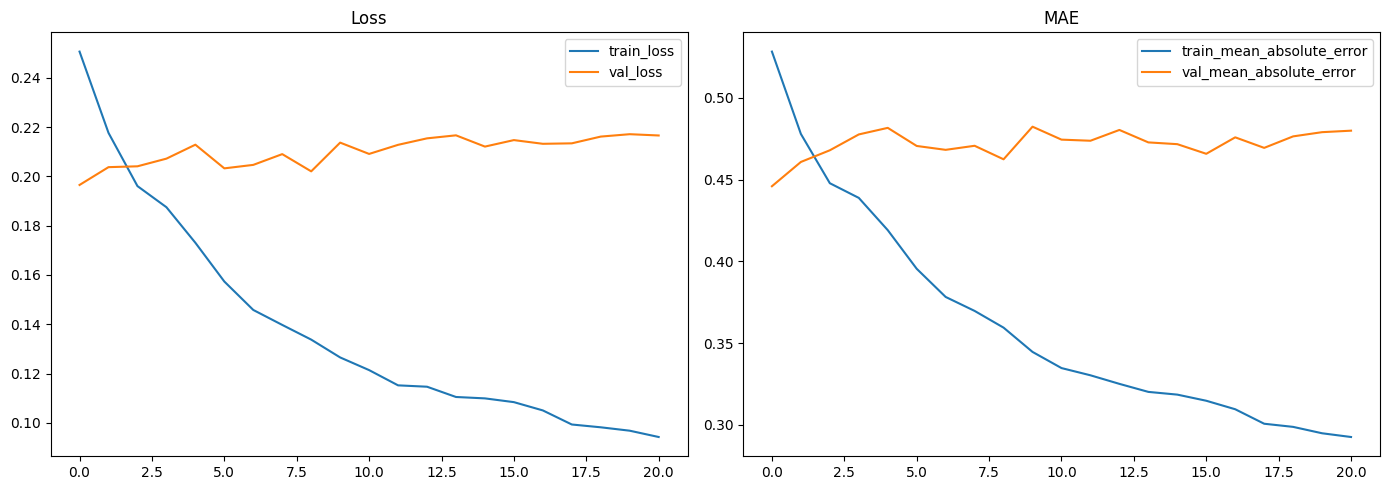

In [19]:
# Plot history (robust terhadap perbedaan nama metric antar versi Keras)
hist_df = pd.DataFrame(history.history)
display(hist_df.tail(3))
print("History columns:", list(hist_df.columns))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df["loss"], label="train_loss")
if "val_loss" in hist_df.columns:
    axes[0].plot(hist_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()

mae_key = None
for candidate in ["mae", "mean_absolute_error"]:
    if candidate in hist_df.columns:
        mae_key = candidate
        break

if mae_key is not None:
    axes[1].plot(hist_df[mae_key], label=f"train_{mae_key}")
    val_mae_key = f"val_{mae_key}"
    if val_mae_key in hist_df.columns:
        axes[1].plot(hist_df[val_mae_key], label=val_mae_key)
    axes[1].set_title("MAE")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "MAE metric tidak ditemukan di history", ha="center", va="center")
    axes[1].set_title("MAE")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [20]:
# Evaluasi test + metrik per target
best_model = keras.models.load_model(str(best_model_path))
test_eval = best_model.evaluate(test_ds, verbose=0)
print("Test evaluate (scaled target) [loss, mae, rmse]:", test_eval)

y_pred_scaled = best_model.predict(X_test, verbose=0)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

metrics = {}
for i, name in enumerate(target_cols):
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    metrics[name] = {"mae": float(mae), "rmse": float(rmse)}

# Metrik sudut dalam derajat (circular error)
s_true = np.rad2deg(np.arctan2(y_test[:, 3], y_test[:, 4])) % 360
s_pred = np.rad2deg(np.arctan2(y_pred[:, 3], y_pred[:, 4])) % 360
angular_err = np.abs((s_pred - s_true + 180) % 360 - 180)
metrics["sudut_deg_circular"] = {
    "mae_deg": float(np.mean(angular_err)),
    "median_deg": float(np.median(angular_err))
}

metrics

Test evaluate (scaled target) [loss, mae, rmse]: [0.2481653243303299, 0.4876965582370758, 0.804465115070343]


{'jarak_km': {'mae': 8.039751052856445, 'rmse': 14.4961484858169},
 'luas_km2': {'mae': 175.5354766845703, 'rmse': 357.7326712260148},
 'radius_km': {'mae': 3.908376693725586, 'rmse': 7.717658208937506},
 'target_sudut_sin': {'mae': 0.5621837377548218, 'rmse': 0.7340023637468492},
 'target_sudut_cos': {'mae': 0.3164355456829071, 'rmse': 0.4681171914176423},
 'sudut_deg_circular': {'mae_deg': 52.487037658691406,
  'median_deg': 33.94682312011719}}

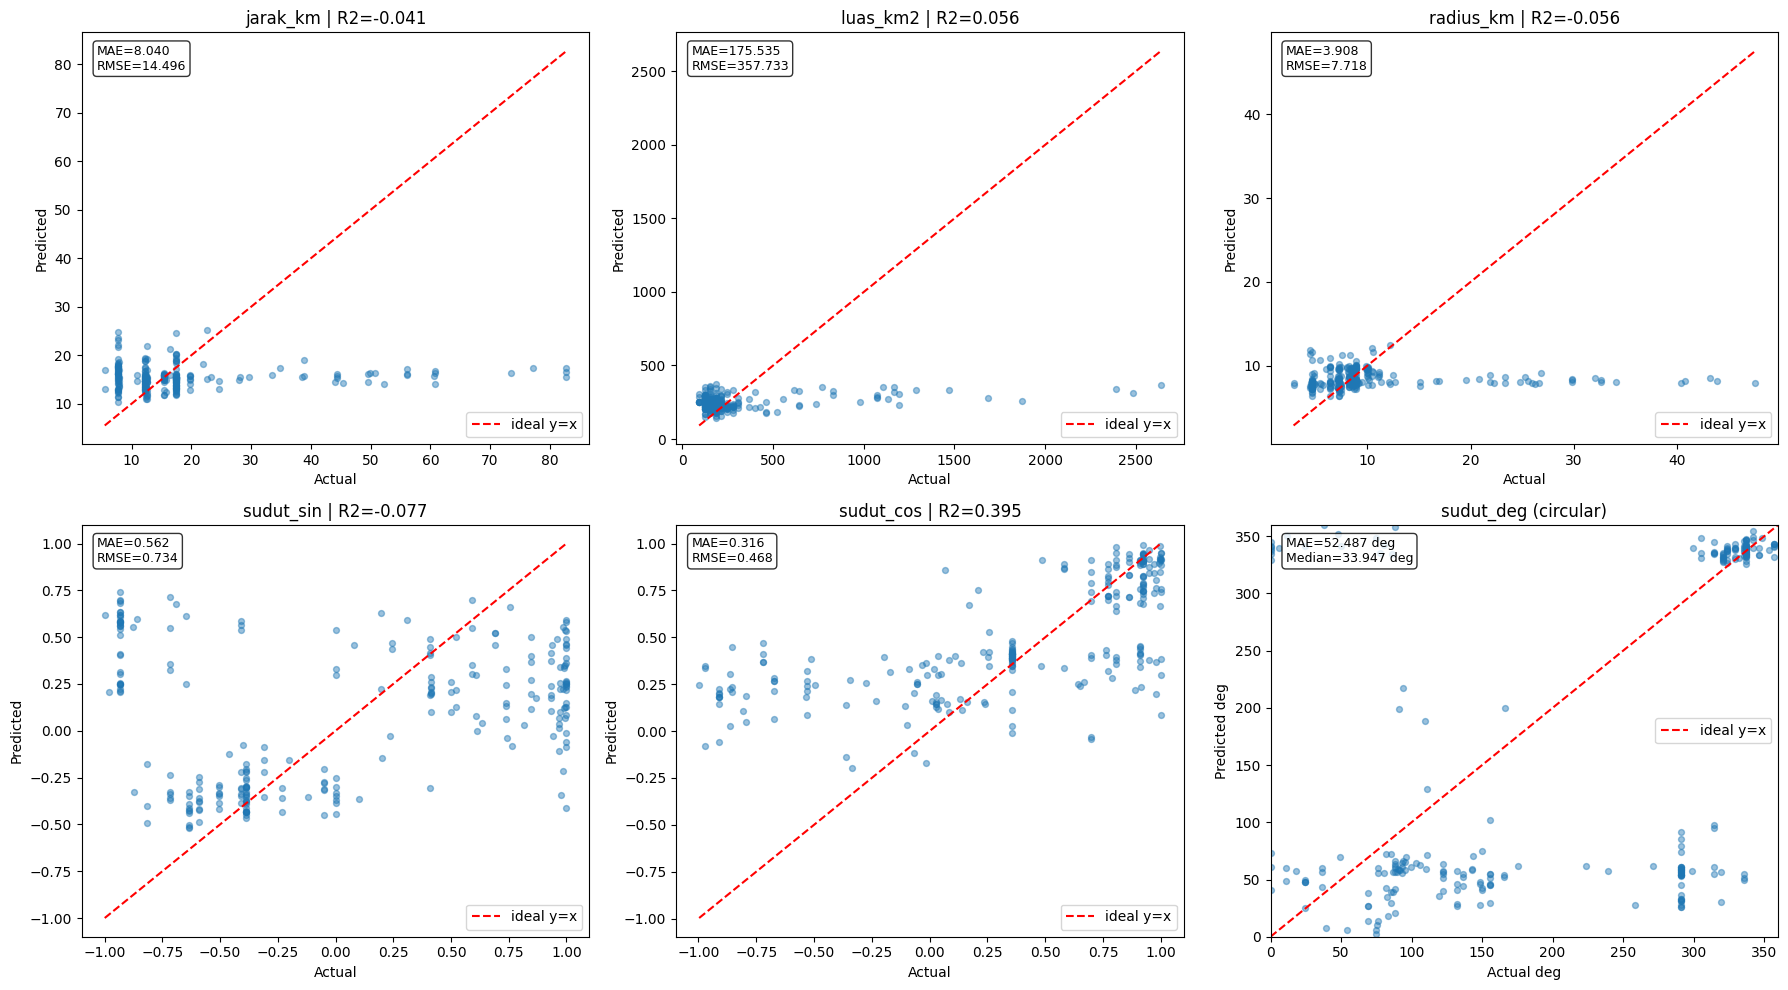

In [21]:
# Plot regresi: aktual vs prediksi untuk tiap target
display_names = ["jarak_km", "luas_km2", "radius_km", "sudut_sin", "sudut_cos"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, name in enumerate(display_names):
    ax = axes[i]
    y_true = y_test[:, i]
    y_hat = y_pred[:, i]

    ax.scatter(y_true, y_hat, alpha=0.45, s=18)

    min_v = min(float(np.min(y_true)), float(np.min(y_hat)))
    max_v = max(float(np.max(y_true)), float(np.max(y_hat)))
    ax.plot([min_v, max_v], [min_v, max_v], linestyle="--", linewidth=1.5, color="red", label="ideal y=x")

    mae_i = mean_absolute_error(y_true, y_hat)
    rmse_i = np.sqrt(mean_squared_error(y_true, y_hat))
    r2_i = r2_score(y_true, y_hat)

    ax.set_title(f"{name} | R2={r2_i:.3f}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(loc="best")
    ax.text(
        0.03, 0.97,
        f"MAE={mae_i:.3f}\nRMSE={rmse_i:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8}
    )

# Plot tambahan untuk sudut dalam derajat (circular)
ax_ang = axes[5]
ax_ang.scatter(s_true, s_pred, alpha=0.45, s=18)
ax_ang.plot([0, 360], [0, 360], linestyle="--", linewidth=1.5, color="red", label="ideal y=x")
ax_ang.set_xlim(0, 360)
ax_ang.set_ylim(0, 360)
ax_ang.set_title("sudut_deg (circular)")
ax_ang.set_xlabel("Actual deg")
ax_ang.set_ylabel("Predicted deg")
ax_ang.legend(loc="best")
ax_ang.text(
    0.03, 0.97,
    f"MAE={np.mean(angular_err):.3f} deg\nMedian={np.median(angular_err):.3f} deg",
    transform=ax_ang.transAxes,
    va="top",
    fontsize=9,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8}
 )

plt.tight_layout()
plt.show()

In [22]:
# Simpan artifacts training
final_model_path = TRAIN_ARTIFACT_DIR / "final_bilstm.keras"
best_model.save(str(final_model_path))

def to_python_number(x):
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    return x

history_serializable = {k: [to_python_number(v) for v in vals] for k, vals in history.history.items()}

history_path = TRAIN_ARTIFACT_DIR / "history.json"
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history_serializable, f, indent=2)

metrics_path = TRAIN_ARTIFACT_DIR / "test_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

with open(TRAIN_ARTIFACT_DIR / "y_scaler.pkl", "wb") as f:
    pickle.dump(y_scaler, f)

training_meta = {
    "input_shape": [int(timesteps), int(n_features)],
    "output_dim": int(n_outputs),
    "epochs_requested": int(EPOCHS),
    "epochs_ran": int(len(history.history.get("loss", []))),
    "batch_size": int(BATCH_SIZE),
    "train_seconds": float(train_seconds),
    "target_scaled": True,
    "feature_cols": feature_cols,
    "target_cols": target_cols
}

with open(TRAIN_ARTIFACT_DIR / "training_metadata.json", "w", encoding="utf-8") as f:
    json.dump(training_meta, f, indent=2)

print("Saved training artifacts:")
for p in sorted(TRAIN_ARTIFACT_DIR.glob("*")):
    print("-", p.name)

Saved training artifacts:
- best_bilstm.keras
- final_bilstm.keras
- history.json
- history_log.csv
- test_metrics.json
- training_metadata.json
- y_scaler.pkl


## Catatan Inferensi

Saat inferensi, output sudut model berasal dari `target_sudut_sin` dan `target_sudut_cos`, lalu diubah ke derajat:
`sudut_deg = (degrees(arctan2(sin, cos)) + 360) % 360`.